In [67]:
import numpy as np
import matplotlib.pyplot as plt

In [68]:
train = np.load('/Users/jackbassham/thesis-rough/data/model_inputs/south/04222026_1201/train.npz')

test = np.load('/Users/jackbassham/thesis-rough/data/model_inputs/south/04222026_1201/test.npz')

In [69]:
def plot_x(input, time_index=0, channel_index=0, title=None):
    plt.pcolormesh(input['x'][time_index, channel_index, :, :])
    plt.colorbar()
    if title is not None:
        plt.title(title)
    plt.show()

In [70]:
def plot_y(input, vector_index, time_index=0, title=None):
    plt.pcolormesh(input['y'][time_index, vector_index, :, :])
    plt.colorbar()
    if title is not None:
        plt.title(title)
    plt.show()

In [71]:
features = [
    'ua_t0',
    'va_t0',
    'ci_t1',
    'mask'
]

targets = [
    'ui_t0',
    'vi_t0',
]

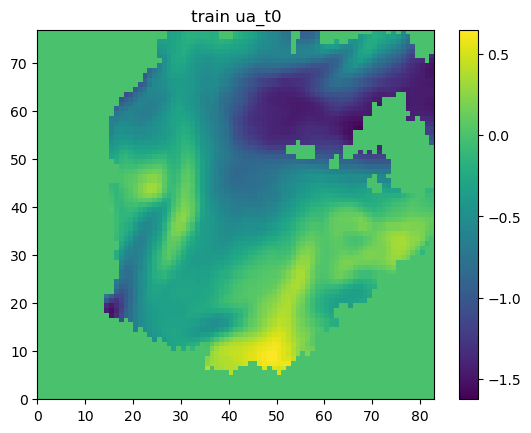

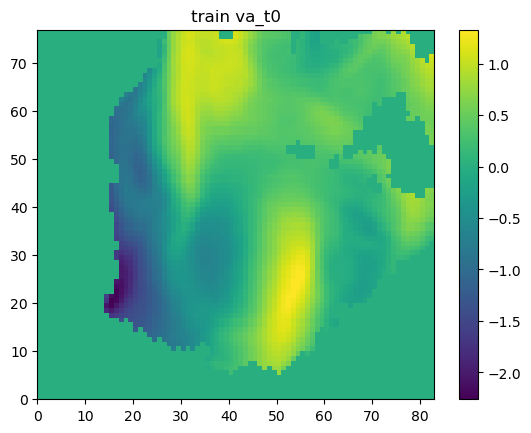

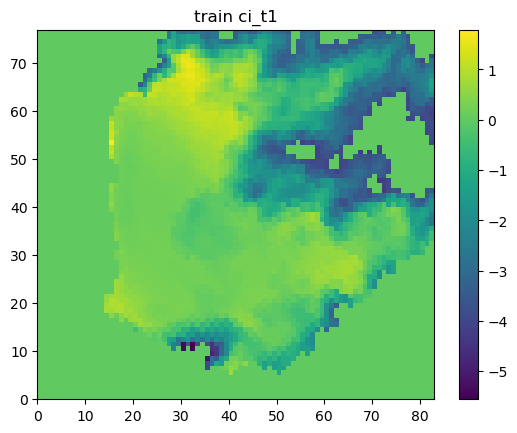

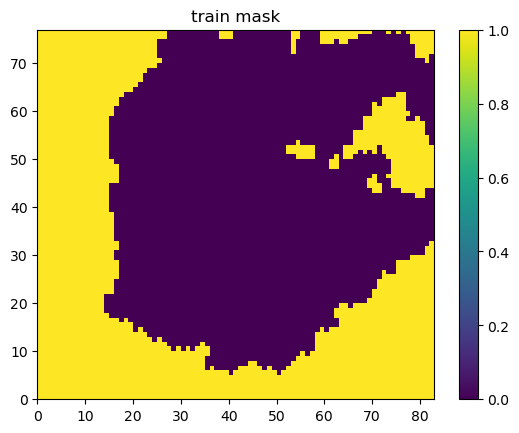

In [72]:
for i, feature in enumerate(features):
    plot_x(train, time_index=0, channel_index=i, title='train ' + feature)

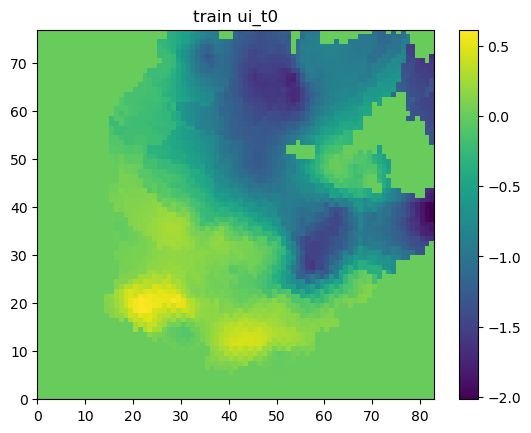

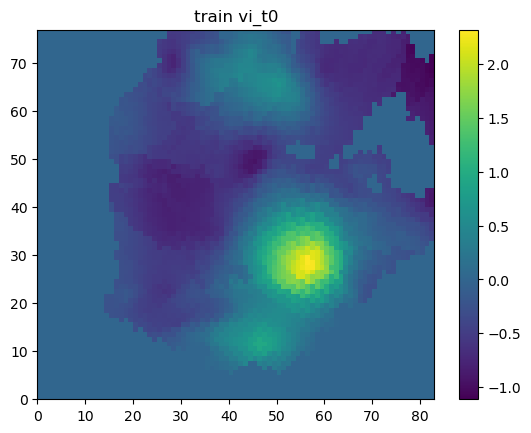

In [73]:
for i, target in enumerate(targets):
    plot_y(train, time_index=0, vector_index=i, title='train ' + target)

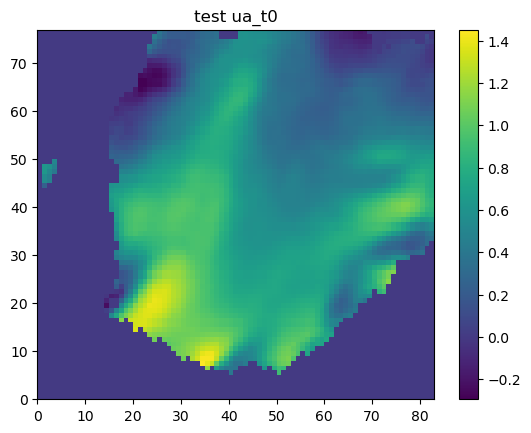

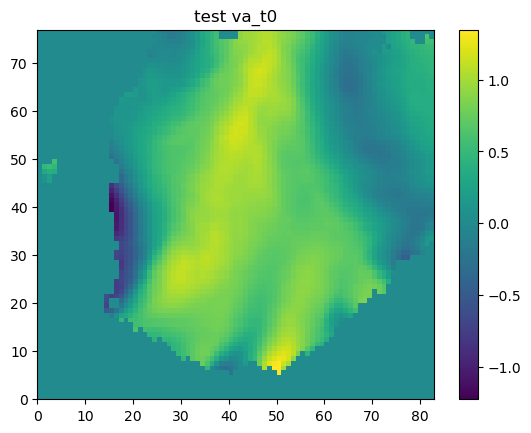

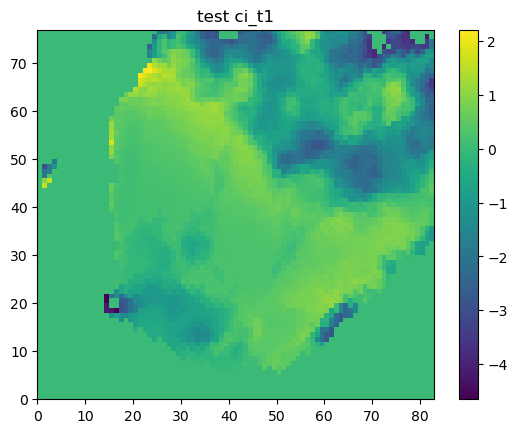

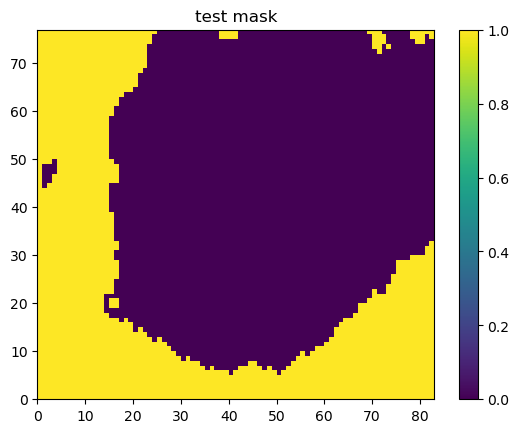

In [74]:
for i, feature in enumerate(features):
    plot_x(test, time_index=0, channel_index=i, title='test ' + feature)

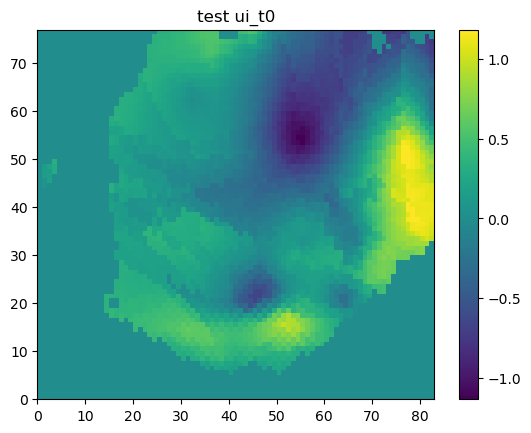

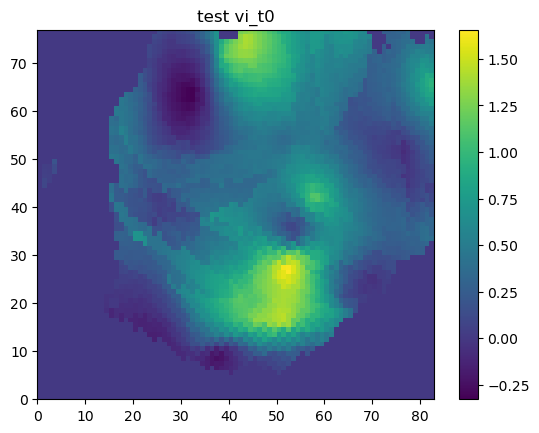

In [75]:
for i, target in enumerate(targets):
    plot_y(test, time_index=0, vector_index=i, title='test ' + target)

In [76]:
preds = np.load('/Users/jackbassham/thesis-rough/data/model-output/lr_cf/south/04222026_1201/preds.npz')

In [77]:
print(preds.keys())

KeysView(NpzFile '/Users/jackbassham/thesis-rough/data/model-output/lr_cf/south/04222026_1201/preds.npz' with keys: y_pred, y_true)


In [78]:
def plot(input, vector_index, time_index=0, key='None', title=None):
    if key is not None:
        plt.pcolormesh(input[key][time_index, vector_index, :, :])
    else:
        plt.pcolormesh(input[time_index, vector_index, :, :])
    plt.colorbar()
    if title is not None:
        plt.title(title)
    plt.show()

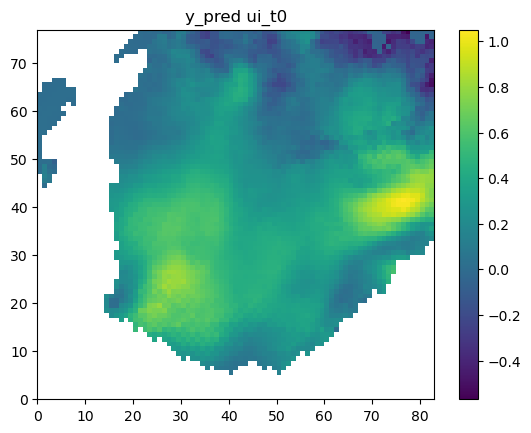

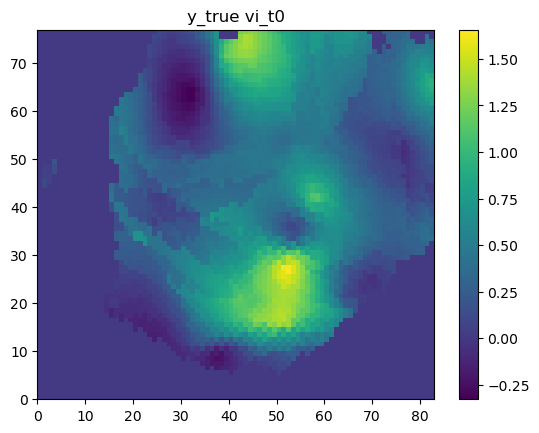

In [79]:
plot(preds, 0, time_index=0, key='y_pred', title='y_pred ui_t0')
plot(preds, 1, time_index=0, key='y_true', title='y_true vi_t0')

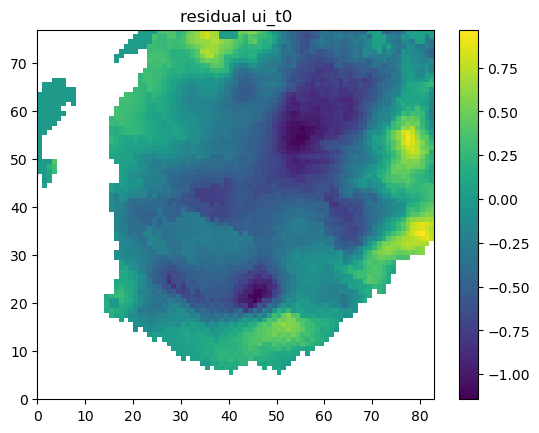

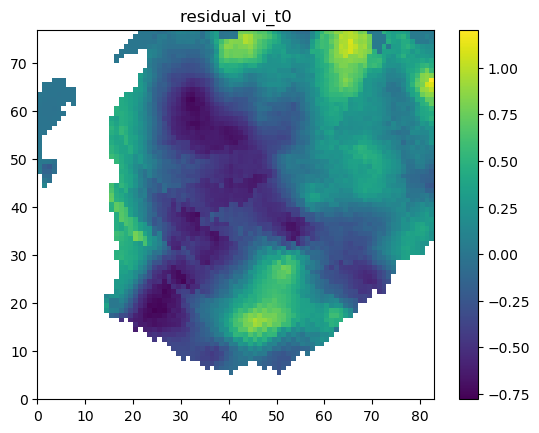

In [80]:
residual = preds['y_true'] - preds['y_pred']

plt.pcolormesh(residual[0, 0, :, :])
plt.colorbar()
plt.title('residual ui_t0')
plt.show()

plt.pcolormesh(residual[0, 1, :, :])
plt.colorbar()
plt.title('residual vi_t0')
plt.show()


In [81]:
coeff = np.load('/Users/jackbassham/thesis-rough/data/model-output/lr_cf/south/04222026_1201/coeffients.npz')

In [82]:
print(coeff.keys())

KeysView(NpzFile '/Users/jackbassham/thesis-rough/data/model-output/lr_cf/south/04222026_1201/coeffients.npz' with keys: arr_0)


In [83]:
coeff['arr_0'].shape

(6, 77, 83)

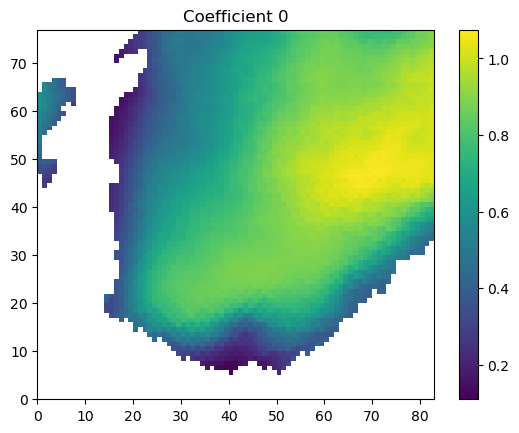

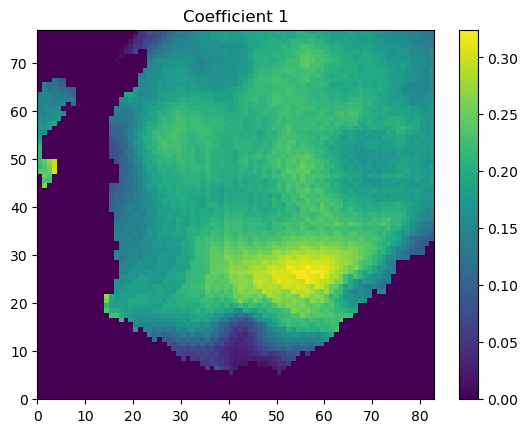

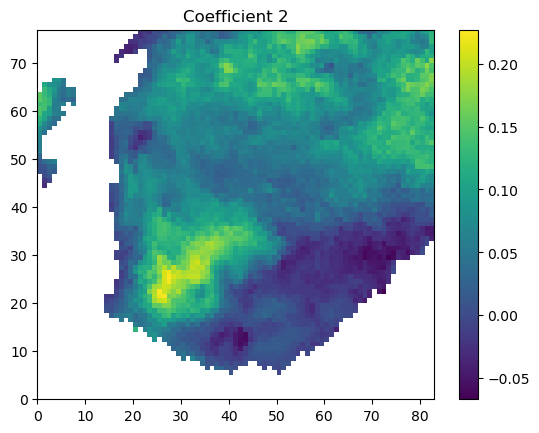

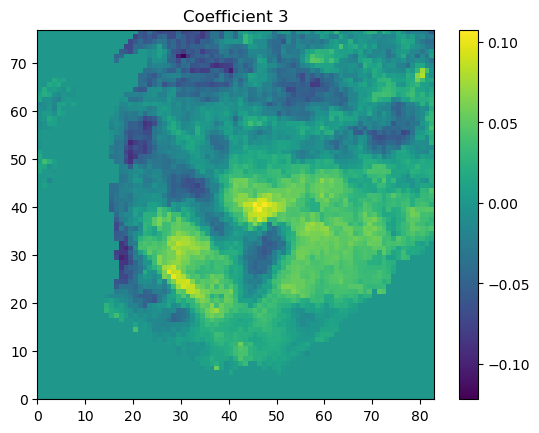

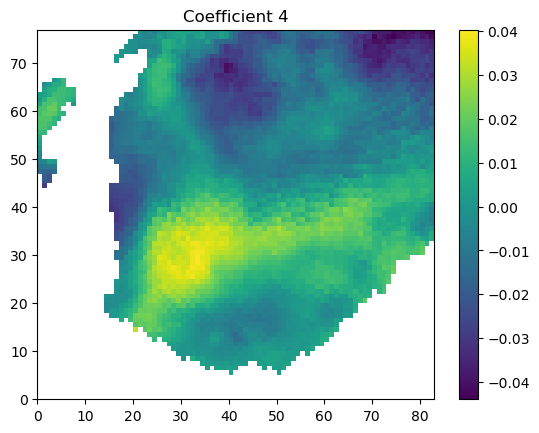

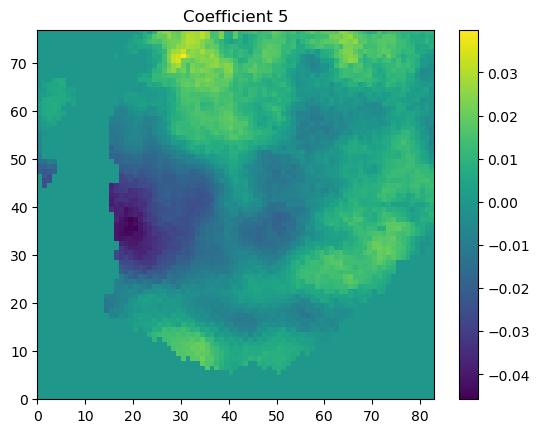

In [84]:
for i in range(coeff['arr_0'].shape[0]):
    plt.pcolormesh(coeff['arr_0'][i, :, :])
    plt.colorbar()
    plt.title(f'Coefficient {i}')
    plt.show()

In [85]:
inputs = np.load('data/model_inputs/south/04282026_1254/targets_features.npz')
print(inputs.keys())

KeysView(NpzFile 'data/model_inputs/south/04282026_1254/targets_features.npz' with keys: y, x, ri_t0)


In [89]:
print(inputs['y'].shape)
print(inputs['x'].shape)
print(inputs['ri_t0'].shape)

(2556, 2, 77, 83)
(2556, 4, 77, 83)
(2556, 1, 77, 83)


In [86]:
split_indices = np.load('data/model_inputs/south/04282026_1254/split_indices.npz')
print(split_indices.keys())

KeysView(NpzFile 'data/model_inputs/south/04282026_1254/split_indices.npz' with keys: test, val, train)


In [90]:
print(split_indices['train'].shape)
print(split_indices['val'].shape)
print(split_indices['test'].shape)


(2, 1096)
(2, 731)
(2, 729)


In [91]:
1096 + 731 + 729

2556

In [92]:
preds = np.load('data/cnn_pt/south/04282026_1254/member_00/preds.npz')

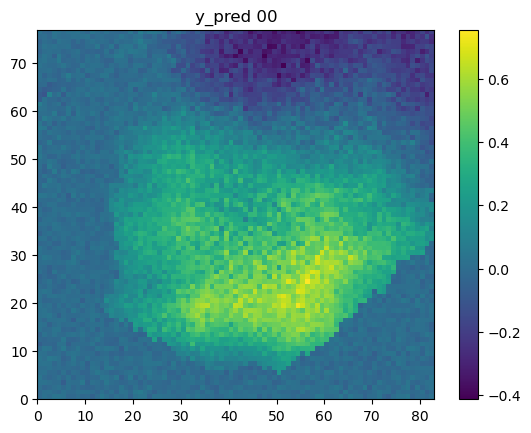

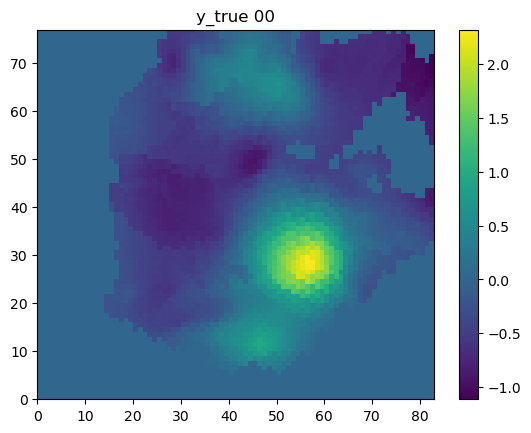

In [94]:
plot(preds, 0, time_index=0, key='y_pred', title='y_pred 00')
plot(preds, 1, time_index=0, key='y_true', title='y_true 00')

In [ ]:
def skill(pred, true, epsilon = 1e-4):
    # NOTE excluding epsilon = 1e-4 from denominator for now

    mse = np.nanmean((true - pred)**2, axis = 0) # mean square error
    # NOTE above is not equivalent to np.nanvar(true-pred), which excludes bias term
    # MSE = E[(y-x)^2]
    # = (E[y-x])^2 + Var(y-x)
    # = bias^2 + Var(y-x)
    # Can prove the above

    truebar = np.nanmean(true, axis = 0) # mean true

    vartrue = np.nanmean((true - truebar)**2, axis = 0) # variance in true
    # NOTE above is equivalent to np.nanvar()

    skill = 1 - mse / (vartrue + epsilon)

    return skill